# Ejemplo 4.2 — Dos pastillas sometidas a un esfuerzo vertical

Hecho por:
* **Michael Heredia Pérez**
* [mherediap@unal.edu.co](mherediap@unal.edu.co)
* 2026-03-17

Generado con _Claude Sonnet 4.6 Extended_. 

## 1. Planteamiento

Dos pastillas cuadradas están apiladas dentro de una caja de **10 cm de arista interior**, tal como se ilustra en la figura 4.28 de Álvarez (2025). Cada pastilla está fabricada con un material **elástico, lineal, homogéneo e isótropo**. El sistema experimenta un incremento uniforme de temperatura $\Delta T = 15°\text{C}$.

| Parámetro | Pastilla 1 | Pastilla 2 |
|:---|:---:|:---:|
| Altura $h$ [m] | 0.25 | 0.12 |
| Módulo de Young $E$ [MPa] | 700 | 400 |
| Coeficiente de Poisson $\nu$ | 0.32 | 0.20 |
| Coef. expansión térmica $\alpha$ [1/°C] | $77\times10^{-6}$ | $9\times10^{-6}$ |

**Objetivo principal:** Determinar el esfuerzo $\sigma_z$ necesario para que el conjunto
se acorte $\Delta h = -1\,\text{mm}$ en dirección $z$, para dos condiciones de borde:

- **Caso 1:** Pastillas **confinadas lateralmente** dentro de la caja $\Rightarrow \varepsilon_x = \varepsilon_y = 0$
- **Caso 2:** Pastillas **sin confinamiento lateral**, solo apiladas $\Rightarrow \sigma_x = \sigma_y = 0$

**Análisis adicionales:**
- Estado tensorial y deformacional completo en cada pastilla
- Dilatación cúbica y cambio de volumen
- Representación gráfica del círculo de Mohr tridimensional
- Análisis de sensibilidad: efecto de $\Delta T$ y $\Delta h$ sobre $\sigma_z$

## 2. Formulación teórica

### 2.1 Ley de Hooke con efectos térmicos (ec. 4.47–4.48, Álvarez 2025)

Para un material elástico lineal isótropo con cambio de temperatura $\Delta T$, la ley
de Hooke generalizada en forma directa es:

$$
\varepsilon_x = \frac{1}{E}(\sigma_x - \nu\sigma_y - \nu\sigma_z) + \alpha\Delta T, \qquad
\varepsilon_y = \frac{1}{E}(\sigma_y - \nu\sigma_x - \nu\sigma_z) + \alpha\Delta T, \qquad
\varepsilon_z = \frac{1}{E}(\sigma_z - \nu\sigma_x - \nu\sigma_y) + \alpha\Delta T
$$

y en forma inversa:

$$
\sigma_{ij} = \lambda\, e\, \delta_{ij} + 2G\,\varepsilon_{ij} + \frac{E\alpha\Delta T}{2\nu - 1}\,\delta_{ij}
$$

donde $e = \varepsilon_x + \varepsilon_y + \varepsilon_z$ es la dilatación cúbica y las
constantes de Lamé son:

$$
\lambda = \frac{E\nu}{(1+\nu)(1-2\nu)}, \qquad G = \frac{E}{2(1+\nu)}
$$


### 2.2 Caso 1: Confinamiento lateral ($\varepsilon_x = \varepsilon_y = 0$)

La dilatación cúbica se reduce a $e = \varepsilon_z$. De la forma inversa de Hooke:

$$
\varepsilon_z = \frac{\sigma_z - c_i}{d_i}, \qquad
c_i = \frac{E_i\,\alpha_i\,\Delta T}{2\nu_i - 1}, \qquad
d_i = \lambda_i + 2G_i
$$

Los esfuerzos laterales de confinamiento (reacción de las paredes) para cada pastilla son:

$$
\sigma_{x,i} = \sigma_{y,i} = \lambda_i\,\varepsilon_{z,i} + c_i
$$

La compatibilidad de desplazamientos $\Delta h = \varepsilon_{z1}h_1 + \varepsilon_{z2}h_2$
conduce a (ec. 4.51, Álvarez 2025):

$$
\boxed{\sigma_z = \frac{d_2\,c_1\,h_1 + d_1\,c_2\,h_2 + d_1\,d_2\,\Delta h}{d_1\,h_2 + d_2\,h_1}}
$$

### 2.3 Caso 2: Sin confinamiento lateral ($\sigma_x = \sigma_y = 0$)

La deformación vertical de cada pastilla es:

$$
\varepsilon_{z,i} = \frac{\sigma_z}{E_i} + \alpha_i\Delta T
$$

Las deformaciones laterales (libres) de cada pastilla son:

$$
\varepsilon_{x,i} = \varepsilon_{y,i} = -\frac{\nu_i\,\sigma_z}{E_i} + \alpha_i\Delta T
$$

La compatibilidad de desplazamientos verticales conduce a:

$$
\boxed{\sigma_z = \frac{E_1 E_2\,\bigl[\Delta h - (\alpha_1 h_1 + \alpha_2 h_2)\Delta T\bigr]}{E_1 h_2 + E_2 h_1}}
$$

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Arc
from matplotlib.gridspec import GridSpec

plt.rcParams.update({'font.size': 10, 'figure.dpi': 130,
                     'axes.grid': True, 'grid.alpha': 0.35})

# ─────────────────────────────────────────────────────────────
# DATOS DEL PROBLEMA (Álvarez 2025, Ejemplo 4.2)
# ─────────────────────────────────────────────────────────────
h1     = 0.25          # [m]    altura pastilla 1
h2     = 0.12          # [m]    altura pastilla 2
dh     = -0.001        # [m]    acortamiento total deseado
dT     = 15.0          # [°C]   incremento de temperatura
lado   = 0.10          # [m]    arista de la sección cuadrada
A      = lado**2       # [m²]   área de la sección transversal

# Propiedades materiales
E1     = 700e6;  nu1 = 0.32;  alpha1 = 77e-6   # Pastilla 1
E2     = 400e6;  nu2 = 0.20;  alpha2 = 9e-6    # Pastilla 2

print("Datos cargados correctamente.")
print(f"Área de la sección: A = {A*1e4:.1f} cm²")

Datos cargados correctamente.
Área de la sección: A = 100.0 cm²


## 3. Funciones auxiliares

In [15]:
# ─────────────────────────────────────────────────────────────
# FUNCIONES AUXILIARES
# ─────────────────────────────────────────────────────────────

def lame_constants(E, nu):
    """Constantes de Lamé λ y G para un material isótropo."""
    lam = E * nu / ((1 + nu) * (1 - 2*nu))
    G   = E / (2 * (1 + nu))
    return lam, G

def modulo_constreniido(lam, G):
    """Módulo constreñido d = λ + 2G."""
    return lam + 2*G

def c_thermal(E, alpha, dT, nu):
    """Constante térmica c = E α ΔT / (2ν − 1) del Caso 1."""
    return E * alpha * dT / (2*nu - 1)

def esfuerzos_principales(sx, sy, sz, txy=0, txz=0, tyz=0):
    """Esfuerzos principales mediante valores propios del tensor de esfuerzos 3×3."""
    sigma = np.array([[sx,  txy, txz],
                      [txy, sy,  tyz],
                      [txz, tyz, sz ]])
    vals = np.sort(np.linalg.eigvalsh(sigma))[::-1]   # σ1 ≥ σ2 ≥ σ3
    return vals

def tau_max(s1, s3):
    """Esfuerzo cortante máximo absoluto."""
    return (s1 - s3) / 2

def dilatacion_cubica(ex, ey, ez):
    """Dilatación cúbica e = εx + εy + εz."""
    return ex + ey + ez

# Constantes de Lamé para cada material
lam1, G1 = lame_constants(E1, nu1)
lam2, G2 = lame_constants(E2, nu2)
M1 = modulo_constreniido(lam1, G1)
M2 = modulo_constreniido(lam2, G2)

print("Constantes elásticas:")
print(f"  Pastilla 1:  λ₁ = {lam1/1e6:8.4f} MPa   G₁ = {G1/1e6:8.4f} MPa   M₁ = {M1/1e6:8.4f} MPa")
print(f"  Pastilla 2:  λ₂ = {lam2/1e6:8.4f} MPa   G₂ = {G2/1e6:8.4f} MPa   M₂ = {M2/1e6:8.4f} MPa")

Constantes elásticas:
  Pastilla 1:  λ₁ = 471.3805 MPa   G₁ = 265.1515 MPa   M₁ = 1001.6835 MPa
  Pastilla 2:  λ₂ = 111.1111 MPa   G₂ = 166.6667 MPa   M₂ = 444.4444 MPa


## 4. Caso 1: Pastillas confinadas lateralmente ($\varepsilon_x = \varepsilon_y = 0$)

In [16]:
# ─────────────────────────────────────────────────────────────
# CASO 1 — CONFINAMIENTO LATERAL
# ─────────────────────────────────────────────────────────────

c1_t = c_thermal(E1, alpha1, dT, nu1)   # constante térmica pastilla 1
c2_t = c_thermal(E2, alpha2, dT, nu2)   # constante térmica pastilla 2
d1   = M1                               # d_i = λ_i + 2G_i = M_i
d2   = M2

# ── Esfuerzo vertical (ec. 4.51, Álvarez 2025) ──────────────
sz_c1 = (d2*c1_t*h1 + d1*c2_t*h2 + d1*d2*dh) / (d1*h2 + d2*h1)
F_c1  = sz_c1 * A

# ── Deformaciones verticales de cada pastilla ────────────────
ez1_c1 = (sz_c1 - c1_t) / d1
ez2_c1 = (sz_c1 - c2_t) / d2
dh_c1  = ez1_c1*h1 + ez2_c1*h2          # verificación

# ── Deformaciones laterales (εx = εy = 0 por definición) ────
ex1_c1 = 0.0;  ey1_c1 = 0.0
ex2_c1 = 0.0;  ey2_c1 = 0.0

# ── Esfuerzos laterales de confinamiento ─────────────────────
#    σx = σy = λ·εz + c   (simetría del plano x-y)
sxy1_c1 = lam1*ez1_c1 + c1_t
sxy2_c1 = lam2*ez2_c1 + c2_t

# ── Dilatación cúbica y cambio de volumen ────────────────────
e1_c1  = dilatacion_cubica(ex1_c1, ey1_c1, ez1_c1)
e2_c1  = dilatacion_cubica(ex2_c1, ey2_c1, ez2_c1)
dV1_c1 = e1_c1 * (A * h1)   # cambio de volumen pastilla 1
dV2_c1 = e2_c1 * (A * h2)

# ── Esfuerzos principales y τmáx ─────────────────────────────
sp1_c1 = esfuerzos_principales(sxy1_c1, sxy1_c1, sz_c1)
sp2_c1 = esfuerzos_principales(sxy2_c1, sxy2_c1, sz_c1)
tm1_c1 = tau_max(sp1_c1[0], sp1_c1[2])
tm2_c1 = tau_max(sp2_c1[0], sp2_c1[2])

print("══════════════════════════════════════════════════════")
print("  CASO 1 — Confinamiento lateral (εx = εy = 0)")
print("══════════════════════════════════════════════════════")
print(f"\n  σz aplicado  = {sz_c1/1e6:>10.6f} MPa")
print(f"  Fuerza F     = {F_c1/1e3:>10.4f} kN")
print(f"  Δh verificado= {dh_c1*1e3:>10.6f} mm\n")
print("  ── Pastilla 1 ──────────────────────────────────")
print(f"  εz₁          = {ez1_c1:>14.6e}")
print(f"  εx₁ = εy₁    = {ex1_c1:>14.6e}  (confinado)")
print(f"  e₁ (dil. cúb)= {e1_c1:>14.6e}")
print(f"  σx₁ = σy₁    = {sxy1_c1/1e6:>10.6f} MPa  (confinamiento)")
print(f"  ΔV₁          = {dV1_c1*1e6:>10.4f} cm³")
print(f"  σ_princ(1)   = [{sp1_c1[0]/1e6:.4f}, {sp1_c1[1]/1e6:.4f}, {sp1_c1[2]/1e6:.4f}] MPa")
print(f"  τmáx(1)      = {tm1_c1/1e6:>10.6f} MPa")
print("  ── Pastilla 2 ──────────────────────────────────")
print(f"  εz₂          = {ez2_c1:>14.6e}")
print(f"  εx₂ = εy₂    = {ex2_c1:>14.6e}  (confinado)")
print(f"  e₂ (dil. cúb)= {e2_c1:>14.6e}")
print(f"  σx₂ = σy₂    = {sxy2_c1/1e6:>10.6f} MPa  (confinamiento)")
print(f"  ΔV₂          = {dV2_c1*1e6:>10.4f} cm³")
print(f"  σ_princ(2)   = [{sp2_c1[0]/1e6:.4f}, {sp2_c1[1]/1e6:.4f}, {sp2_c1[2]/1e6:.4f}] MPa")
print(f"  τmáx(2)      = {tm2_c1/1e6:>10.6f} MPa")

══════════════════════════════════════════════════════
  CASO 1 — Confinamiento lateral (εx = εy = 0)
══════════════════════════════════════════════════════

  σz aplicado  =  -3.050185 MPa
  Fuerza F     =   -30.5019 kN
  Δh verificado=  -1.000000 mm

  ── Pastilla 1 ──────────────────────────────────
  εz₁          =  -8.030000e-04
  εx₁ = εy₁    =   0.000000e+00  (confinado)
  e₁ (dil. cúb)=  -8.030000e-04
  σx₁ = σy₁    =  -2.624352 MPa  (confinamiento)
  ΔV₁          =    -2.0075 cm³
  σ_princ(1)   = [-2.6244, -2.6244, -3.0502] MPa
  τmáx(1)      =   0.212917 MPa
  ── Pastilla 2 ──────────────────────────────────
  εz₂          =  -6.660417e-03
  εx₂ = εy₂    =   0.000000e+00  (confinado)
  e₂ (dil. cúb)=  -6.660417e-03
  σx₂ = σy₂    =  -0.830046 MPa  (confinamiento)
  ΔV₂          =    -7.9925 cm³
  σ_princ(2)   = [-0.8300, -0.8300, -3.0502] MPa
  τmáx(2)      =   1.110069 MPa


## 5. Caso 2: Pastillas sin confinamiento lateral ($\sigma_x = \sigma_y = 0$)

In [17]:
# ─────────────────────────────────────────────────────────────
# CASO 2 — SIN CONFINAMIENTO LATERAL
# ─────────────────────────────────────────────────────────────

# ── Esfuerzo vertical ────────────────────────────────────────
sz_c2 = (E1*E2*(dh - (alpha1*h1 + alpha2*h2)*dT)) / (E1*h2 + E2*h1)
F_c2  = sz_c2 * A

# ── Deformaciones verticales ─────────────────────────────────
ez1_c2 = sz_c2/E1 + alpha1*dT
ez2_c2 = sz_c2/E2 + alpha2*dT
dh_c2  = ez1_c2*h1 + ez2_c2*h2           # verificación

# ── Deformaciones laterales libres ───────────────────────────
#    εx = εy = −ν σz / E + α ΔT
ex1_c2 = -nu1*sz_c2/E1 + alpha1*dT
ex2_c2 = -nu2*sz_c2/E2 + alpha2*dT
ey1_c2 = ex1_c2;  ey2_c2 = ex2_c2         # simetría

# ── Cambios de dimensión lateral (pastillas cuadradas) ───────
dlado1 = ex1_c2 * lado    # expansión/contracción lateral pastilla 1
dlado2 = ex2_c2 * lado

# ── Dilatación cúbica y cambio de volumen ────────────────────
e1_c2  = dilatacion_cubica(ex1_c2, ey1_c2, ez1_c2)
e2_c2  = dilatacion_cubica(ex2_c2, ey2_c2, ez2_c2)
dV1_c2 = e1_c2 * (A * h1)
dV2_c2 = e2_c2 * (A * h2)

# ── Esfuerzos principales y τmáx ─────────────────────────────
sp1_c2 = esfuerzos_principales(0.0, 0.0, sz_c2)
sp2_c2 = esfuerzos_principales(0.0, 0.0, sz_c2)
tm1_c2 = tau_max(sp1_c2[0], sp1_c2[2])
tm2_c2 = tau_max(sp2_c2[0], sp2_c2[2])

print("══════════════════════════════════════════════════════")
print("  CASO 2 — Sin confinamiento lateral (σx = σy = 0)")
print("══════════════════════════════════════════════════════")
print(f"\n  σz aplicado  = {sz_c2/1e6:>10.6f} MPa")
print(f"  Fuerza F     = {F_c2/1e3:>10.5f} kN")
print(f"  Δh verificado= {dh_c2*1e3:>10.6f} mm\n")
print("  ── Pastilla 1 ──────────────────────────────────")
print(f"  εz₁          = {ez1_c2:>14.6e}")
print(f"  εx₁ = εy₁    = {ex1_c2:>14.6e}  (libre)")
print(f"  Δlado₁       = {dlado1*1e3:>10.4f} mm")
print(f"  e₁ (dil. cúb)= {e1_c2:>14.6e}")
print(f"  ΔV₁          = {dV1_c2*1e6:>10.4f} cm³")
print(f"  σ_princ(1)   = [{sp1_c2[0]/1e6:.4f}, {sp1_c2[1]/1e6:.4f}, {sp1_c2[2]/1e6:.4f}] MPa")
print(f"  τmáx(1)      = {tm1_c2/1e6:>10.6f} MPa")
print("  ── Pastilla 2 ──────────────────────────────────")
print(f"  εz₂          = {ez2_c2:>14.6e}")
print(f"  εx₂ = εy₂    = {ex2_c2:>14.6e}  (libre)")
print(f"  Δlado₂       = {dlado2*1e3:>10.4f} mm")
print(f"  e₂ (dil. cúb)= {e2_c2:>14.6e}")
print(f"  ΔV₂          = {dV2_c2*1e6:>10.4f} cm³")
print(f"  σ_princ(2)   = [{sp2_c2[0]/1e6:.4f}, {sp2_c2[1]/1e6:.4f}, {sp2_c2[2]/1e6:.4f}] MPa")
print(f"  τmáx(2)      = {tm2_c2/1e6:>10.6f} MPa")

══════════════════════════════════════════════════════
  CASO 2 — Sin confinamiento lateral (σx = σy = 0)
══════════════════════════════════════════════════════

  σz aplicado  =  -1.985793 MPa
  Fuerza F     =  -19.85793 kN
  Δh verificado=  -1.000000 mm

  ── Pastilla 1 ──────────────────────────────────
  εz₁          =  -1.681848e-03
  εx₁ = εy₁    =   2.062791e-03  (libre)
  Δlado₁       =     0.2063 mm
  e₁ (dil. cúb)=   2.443735e-03
  ΔV₁          =     6.1093 cm³
  σ_princ(1)   = [0.0000, 0.0000, -1.9858] MPa
  τmáx(1)      =   0.992897 MPa
  ── Pastilla 2 ──────────────────────────────────
  εz₂          =  -4.829484e-03
  εx₂ = εy₂    =   1.127897e-03  (libre)
  Δlado₂       =     0.1128 mm
  e₂ (dil. cúb)=  -2.573690e-03
  ΔV₂          =    -3.0884 cm³
  σ_princ(2)   = [0.0000, 0.0000, -1.9858] MPa
  τmáx(2)      =   0.992897 MPa


## 6. Resumen comparativo

In [18]:
# ─────────────────────────────────────────────────────────────
# TABLA RESUMEN COMPARATIVO
# ─────────────────────────────────────────────────────────────
sep  = "═" * 64
sep2 = "─" * 64
fmt  = "{:<32} {:>14} {:>14}"

print(sep)
print(f"{'RESUMEN COMPARATIVO':^64}")
print(sep)
print(fmt.format("Magnitud", "Caso 1", "Caso 2"))
print(sep2)
print(fmt.format("σz  [MPa]",
                 f"{sz_c1/1e6:.5f}", f"{sz_c2/1e6:.5f}"))
print(fmt.format("F   [kN]",
                 f"{F_c1/1e3:.4f}", f"{F_c2/1e3:.4f}"))
print(sep2)
print(fmt.format("εz₁",
                 f"{ez1_c1:.4e}", f"{ez1_c2:.4e}"))
print(fmt.format("εx₁ = εy₁",
                 f"{ex1_c1:.4e}", f"{ex1_c2:.4e}"))
print(fmt.format("σx₁ = σy₁  [MPa]",
                 f"{sxy1_c1/1e6:.5f}", "0.00000"))
print(fmt.format("e₁ (dil. cúbica)",
                 f"{e1_c1:.4e}", f"{e1_c2:.4e}"))
print(fmt.format("ΔV₁  [cm³]",
                 f"{dV1_c1*1e6:.5f}", f"{dV1_c2*1e6:.5f}"))
print(sep2)
print(fmt.format("εz₂",
                 f"{ez2_c1:.4e}", f"{ez2_c2:.4e}"))
print(fmt.format("εx₂ = εy₂",
                 f"{ex2_c1:.4e}", f"{ex2_c2:.4e}"))
print(fmt.format("σx₂ = σy₂  [MPa]",
                 f"{sxy2_c1/1e6:.5f}", "0.00000"))
print(fmt.format("e₂ (dil. cúbica)",
                 f"{e2_c1:.4e}", f"{e2_c2:.4e}"))
print(fmt.format("ΔV₂  [cm³]",
                 f"{dV2_c1*1e6:.5f}", f"{dV2_c2*1e6:.5f}"))
print(sep2)
print(fmt.format("τmáx pastilla 1  [MPa]",
                 f"{tm1_c1/1e6:.5f}", f"{tm1_c2/1e6:.5f}"))
print(fmt.format("τmáx pastilla 2  [MPa]",
                 f"{tm2_c1/1e6:.5f}", f"{tm2_c2/1e6:.5f}"))
print(sep)
razon = abs(sz_c1/sz_c2)
print(f"\nCaso 1 requiere {razon:.3f}× más esfuerzo que el Caso 2.")
print("El confinamiento lateral incrementa la rigidez aparente")
print("porque el módulo constreñido M = λ+2G > E.")

════════════════════════════════════════════════════════════════
                      RESUMEN COMPARATIVO                       
════════════════════════════════════════════════════════════════
Magnitud                                 Caso 1         Caso 2
────────────────────────────────────────────────────────────────
σz  [MPa]                              -3.05019       -1.98579
F   [kN]                               -30.5019       -19.8579
────────────────────────────────────────────────────────────────
εz₁                                 -8.0300e-04    -1.6818e-03
εx₁ = εy₁                            0.0000e+00     2.0628e-03
σx₁ = σy₁  [MPa]                       -2.62435        0.00000
e₁ (dil. cúbica)                    -8.0300e-04     2.4437e-03
ΔV₁  [cm³]                             -2.00750        6.10934
────────────────────────────────────────────────────────────────
εz₂                                 -6.6604e-03    -4.8295e-03
εx₂ = εy₂                            0.0000

## 7. Visualizaciones
### 7.1 Esquema del problema y estado deformado

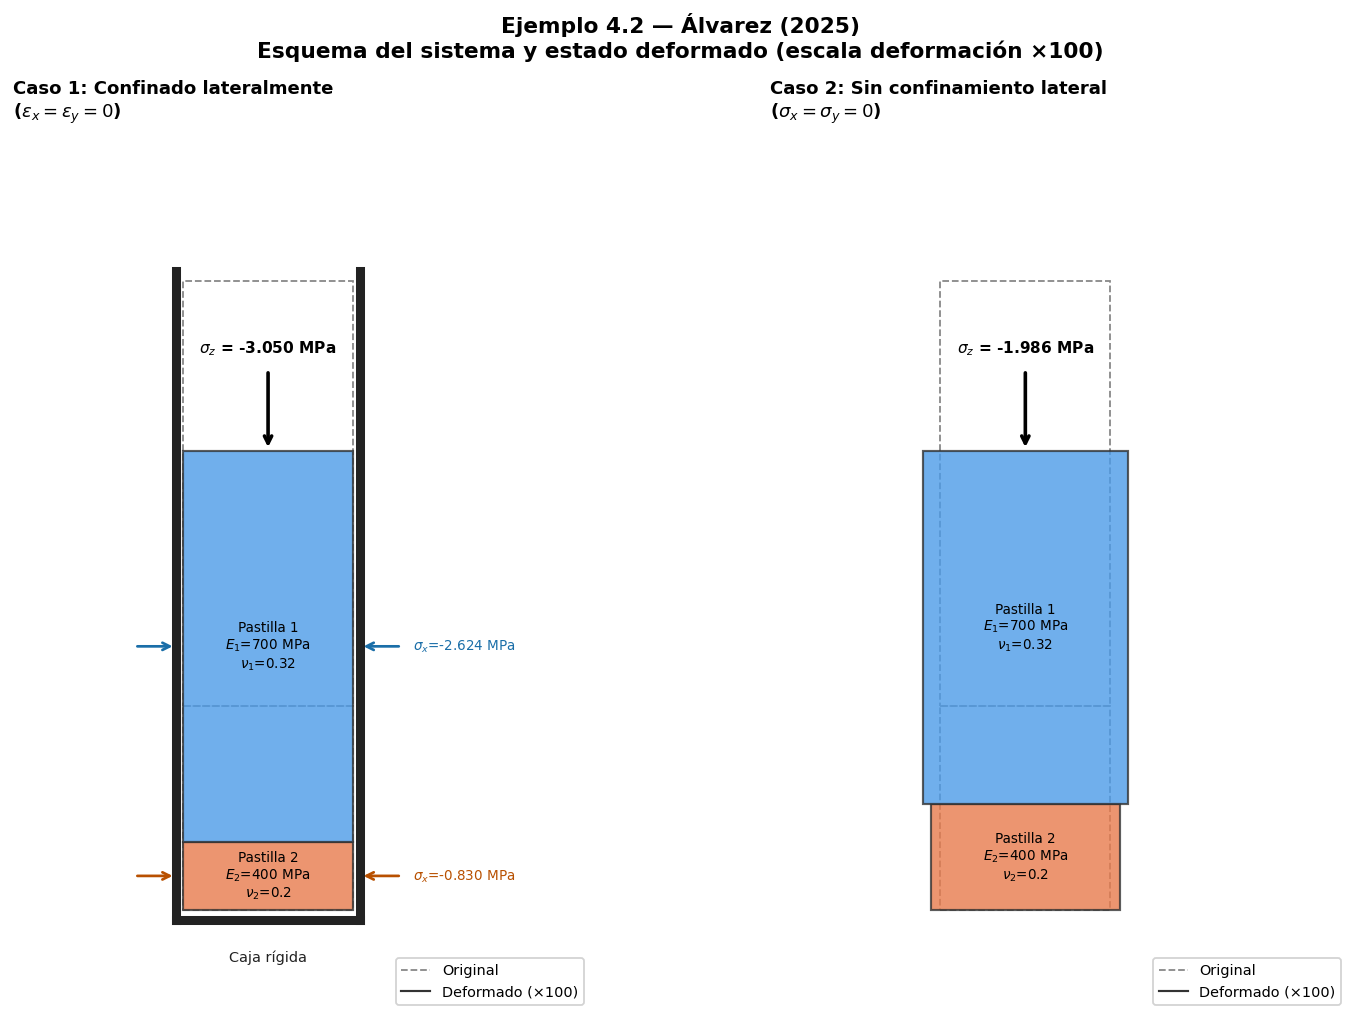

In [19]:
# ─────────────────────────────────────────────────────────────
# FIGURA 1: Esquema + estado deformado  (versión corregida)
# ─────────────────────────────────────────────────────────────
ESC = 100   # factor de escala visual de deformaciones

def dibujar_sistema(ax, titulo, subtitulo,
                    ez1, ez2, ex1_p1, ex2_p2,
                    sz_val, sxy1, sxy2,
                    con_caja=True):

    ax.set_xlim(-0.10, 0.24)
    ax.set_ylim(-0.06, 0.46)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(titulo + '\n' + subtitulo,
                 fontsize=10, fontweight='bold', loc='left')

    x0, w = 0.0, lado

    # Contornos originales (línea punteada)
    for y0, h in [(0.0, h2), (h2, h1)]:
        rect = mpatches.Rectangle((x0, y0), w, h,
                                   fill=False, edgecolor='#888888',
                                   linestyle='--', linewidth=1.0)
        ax.add_patch(rect)

    # Estado deformado — pastilla 2
    dw2 = ex2_p2 * w * ESC
    dh2 = ez2    * h2 * ESC
    rect2 = mpatches.FancyBboxPatch(
        (x0 - dw2/2, 0.0), w + dw2, h2 + dh2,
        boxstyle='square,pad=0',
        facecolor='#E87B4C', edgecolor='#333', linewidth=1.2, alpha=0.80)
    ax.add_patch(rect2)
    cy2 = (h2 + dh2) / 2
    ax.text(x0 + w/2, cy2,
            f'Pastilla 2\n$E_2$={E2/1e6:.0f} MPa\n$\\nu_2$={nu2}',
            ha='center', va='center', fontsize=7.5, color='k')

    # Estado deformado — pastilla 1
    dw1 = ex1_p1 * w * ESC
    dh1 = ez1    * h1 * ESC
    base1 = h2 + dh2
    rect1 = mpatches.FancyBboxPatch(
        (x0 - dw1/2, base1), w + dw1, h1 + dh1,
        boxstyle='square,pad=0',
        facecolor='#4C9BE8', edgecolor='#333', linewidth=1.2, alpha=0.80)
    ax.add_patch(rect1)
    ax.text(x0 + w/2, base1 + (h1 + dh1)/2,
            f'Pastilla 1\n$E_1$={E1/1e6:.0f} MPa\n$\\nu_1$={nu1}',
            ha='center', va='center', fontsize=7.5, color='k')

    ytop = base1 + h1 + dh1

    # Caja rígida (Caso 1)
    if con_caja:
        for xw in [x0 - 0.004, x0 + w + 0.004]:
            ax.plot([xw, xw], [-0.006, h1+h2+0.006],
                    color='#222', lw=5)
        ax.plot([x0-0.004, x0+w+0.004], [-0.006, -0.006],
                color='#222', lw=5)
        ax.text(x0 + w/2, -0.030, 'Caja rígida',
                ha='center', fontsize=8, color='#222')

    # Flecha σz
    ax.annotate('', xy=(x0+w/2, ytop),
                xytext=(x0+w/2, ytop+0.048),
                arrowprops=dict(arrowstyle='->', color='k', lw=2.0))
    ax.text(x0+w/2, ytop+0.055,
            f'$\\sigma_z$ = {sz_val/1e6:.3f} MPa',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')

    # Flechas σx — pastilla 1
    if abs(sxy1) > 1:
        ymid1 = base1 + (h1+dh1)/2
        for xarr, dx in [(x0-0.004, -0.025), (x0+w+0.004, 0.025)]:
            ax.annotate('', xy=(xarr, ymid1),
                        xytext=(xarr+dx, ymid1),
                        arrowprops=dict(arrowstyle='->',
                                        color='#1a6ea8', lw=1.5))
        ax.text(x0+w+0.035, ymid1,
                f'$\\sigma_x$={sxy1/1e6:.3f} MPa',
                ha='left', va='center', fontsize=7.5, color='#1a6ea8')

    # Flechas σx — pastilla 2
    if abs(sxy2) > 1:
        ymid2 = cy2
        for xarr, dx in [(x0-0.004, -0.025), (x0+w+0.004, 0.025)]:
            ax.annotate('', xy=(xarr, ymid2),
                        xytext=(xarr+dx, ymid2),
                        arrowprops=dict(arrowstyle='->',
                                        color='#b85000', lw=1.5))
        ax.text(x0+w+0.035, ymid2,
                f'$\\sigma_x$={sxy2/1e6:.3f} MPa',
                ha='left', va='center', fontsize=7.5, color='#b85000')

    # Leyenda
    ax.plot([], [], color='#888', ls='--', lw=1, label='Original')
    ax.plot([], [], color='#333', lw=1.2, label=f'Deformado (×{ESC})')
    ax.legend(fontsize=8, loc='lower right', framealpha=0.85, edgecolor='#ccc')


fig, axes = plt.subplots(1, 2, figsize=(12, 8))

dibujar_sistema(axes[0],
    'Caso 1: Confinado lateralmente',
    r'($\varepsilon_x = \varepsilon_y = 0$)',
    ez1_c1, ez2_c1, ex1_c1, ex2_c1,
    sz_c1, sxy1_c1, sxy2_c1, con_caja=True)

dibujar_sistema(axes[1],
    'Caso 2: Sin confinamiento lateral',
    r'($\sigma_x = \sigma_y = 0$)',
    ez1_c2, ez2_c2, ex1_c2, ex2_c2,
    sz_c2, 0.0, 0.0, con_caja=False)

fig.suptitle(
    'Ejemplo 4.2 — Álvarez (2025)\n'
    f'Esquema del sistema y estado deformado (escala deformación ×{ESC})',
    fontsize=12, fontweight='bold')

plt.tight_layout()
#plt.savefig('fig1_esquema.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Círculo de Mohr tridimensional

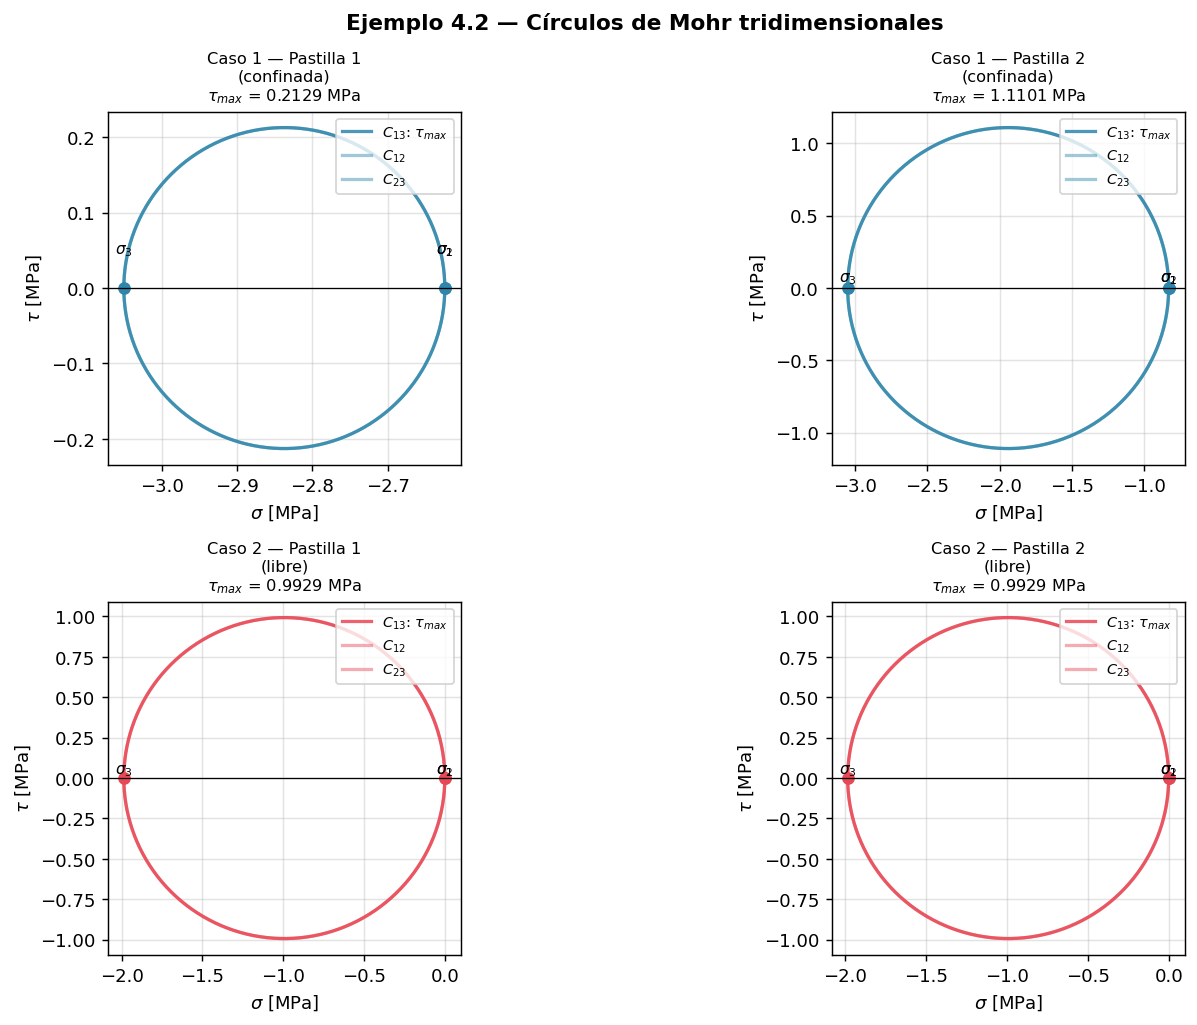

In [20]:
# ─────────────────────────────────────────────────────────────
# FIGURA 2: Círculo de Mohr tridimensional
# ─────────────────────────────────────────────────────────────
def mohr3d(ax, s_princ, titulo, color):
    """Dibuja los tres círculos de Mohr para un estado tridimensional."""
    s1, s2, s3 = np.sort(s_princ)[::-1]   # σ1 ≥ σ2 ≥ σ3

    pares = [(s1, s3), (s1, s2), (s2, s3)]
    alphas = [0.85, 0.45, 0.45]
    labels = [r'$C_{13}$: $\tau_{max}$', r'$C_{12}$', r'$C_{23}$']

    for (sa, sb), alpha, lbl in zip(pares, alphas, labels):
        centro = (sa + sb) / 2
        radio  = abs(sa - sb) / 2
        theta  = np.linspace(0, np.pi, 300)
        xc = centro + radio * np.cos(theta)
        yc = radio  * np.sin(theta)
        ax.plot(xc/1e6, yc/1e6, color=color, lw=1.8,
                alpha=alpha, label=lbl)
        ax.plot(xc/1e6, -yc/1e6, color=color, lw=1.8, alpha=alpha)

    # Esfuerzos principales
    for s_val, lbl in zip([s1, s2, s3],
                           [r'$\sigma_1$', r'$\sigma_2$', r'$\sigma_3$']):
        ax.plot(s_val/1e6, 0, 'o', color=color, ms=6)
        ax.text(s_val/1e6, 0.015*abs(s3/1e6), lbl,
                ha='center', fontsize=8.5)

    tau_max_val = (s1 - s3) / 2
    ax.axhline(0, color='k', lw=0.7)
    ax.set_xlabel(r'$\sigma$ [MPa]', fontsize=10)
    ax.set_ylabel(r'$\tau$ [MPa]', fontsize=10)
    ax.set_title(titulo + f'\n$\\tau_{{max}}$ = {tau_max_val/1e6:.4f} MPa',
                 fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_aspect('equal')


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

mohr3d(axes[0,0], sp1_c1,
       'Caso 1 — Pastilla 1\n(confinada)', '#2E86AB')
mohr3d(axes[0,1], sp2_c1,
       'Caso 1 — Pastilla 2\n(confinada)', '#2E86AB')
mohr3d(axes[1,0], sp1_c2,
       'Caso 2 — Pastilla 1\n(libre)', '#E84855')
mohr3d(axes[1,1], sp2_c2,
       'Caso 2 — Pastilla 2\n(libre)', '#E84855')

fig.suptitle('Ejemplo 4.2 — Círculos de Mohr tridimensionales',
             fontsize=12, fontweight='bold')
plt.tight_layout()
#plt.savefig('fig2_mohr3d.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Estado tensorial y deformacional de cada pastilla

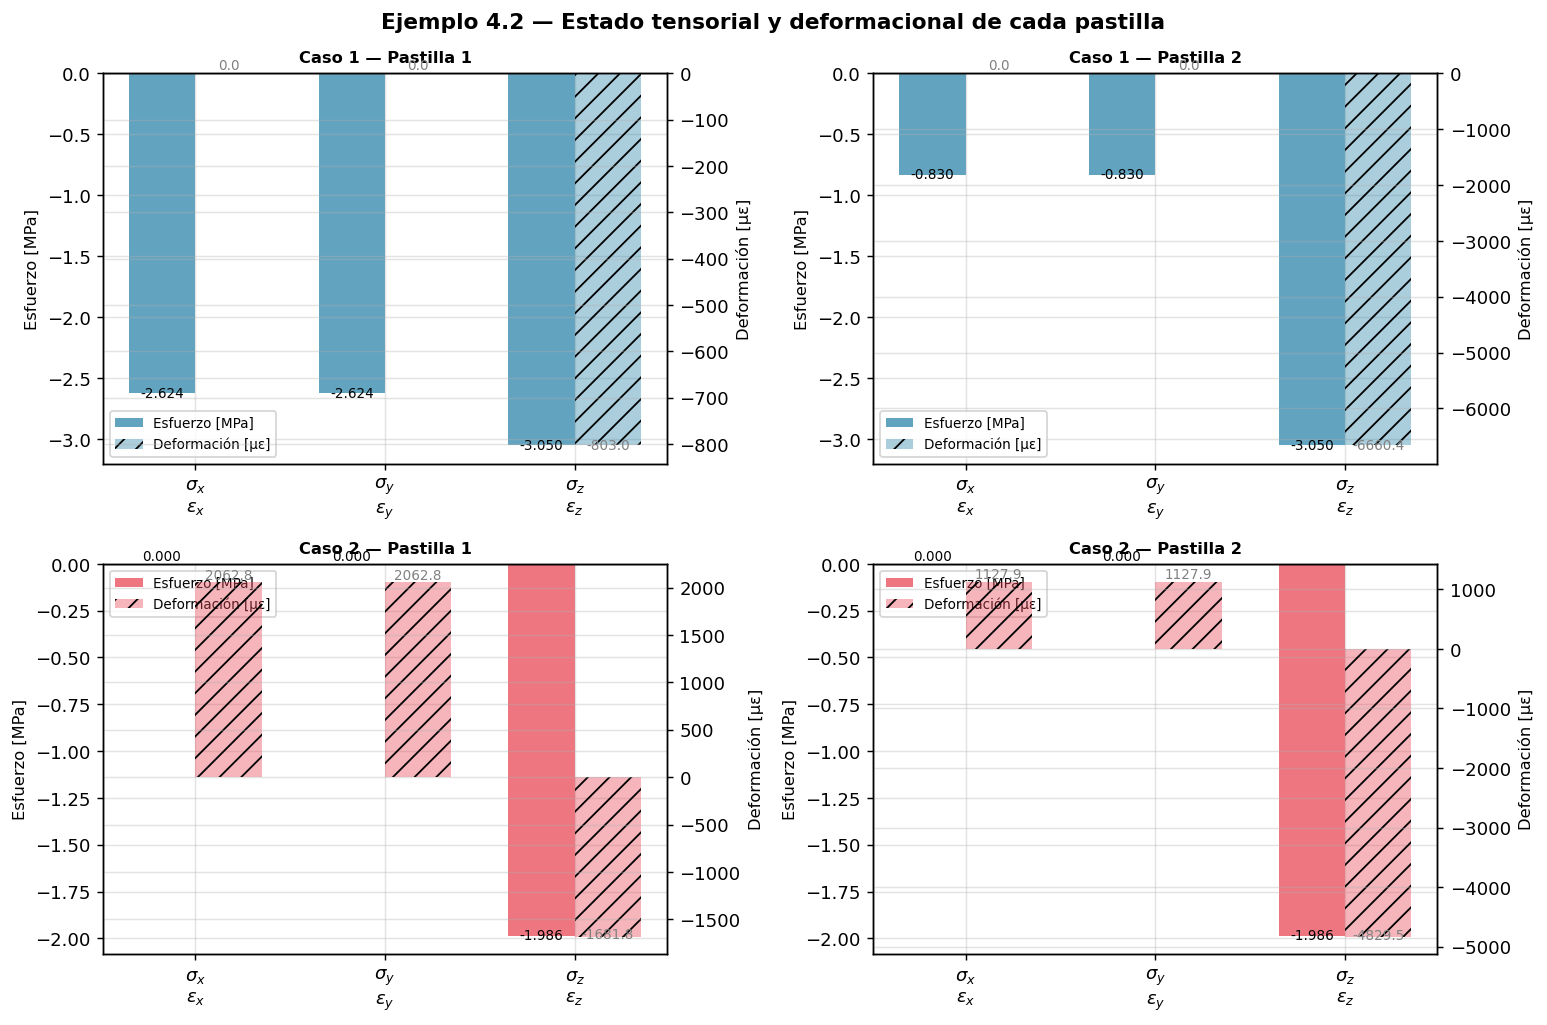

In [21]:
# ─────────────────────────────────────────────────────────────
# FIGURA 3: Estado tensorial y deformacional completo
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

casos = [
    # (título, sx1, sy1, sz, ex1, ey1, ez1, color)
    ('Caso 1 — Pastilla 1',
     sxy1_c1, sxy1_c1, sz_c1,
     ex1_c1,  ey1_c1,  ez1_c1, '#2E86AB'),
    ('Caso 1 — Pastilla 2',
     sxy2_c1, sxy2_c1, sz_c1,
     ex2_c1,  ey2_c1,  ez2_c1, '#2E86AB'),
    ('Caso 2 — Pastilla 1',
     0.0,     0.0,     sz_c2,
     ex1_c2,  ey1_c2,  ez1_c2, '#E84855'),
    ('Caso 2 — Pastilla 2',
     0.0,     0.0,     sz_c2,
     ex2_c2,  ey2_c2,  ez2_c2, '#E84855'),
]

etiquetas_s = [r'$\sigma_x$', r'$\sigma_y$', r'$\sigma_z$']
etiquetas_e = [r'$\varepsilon_x$', r'$\varepsilon_y$', r'$\varepsilon_z$']

for ax, (titulo, sx, sy, sz, ex, ey, ez, col) in zip(axes.flat, casos):
    valores_s = np.array([sx, sy, sz]) / 1e6
    valores_e = np.array([ex, ey, ez]) * 1e6   # escala en µε

    x = np.arange(3)
    w = 0.35

    ax2 = ax.twinx()

    b1 = ax.bar(x - w/2, valores_s, w, color=col, alpha=0.75,
                label='Esfuerzo [MPa]')
    b2 = ax2.bar(x + w/2, valores_e, w, color=col, alpha=0.40,
                 hatch='//', label='Deformación [µε]')

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f'{es}\n{ee}' for es, ee in zip(etiquetas_s, etiquetas_e)],
        fontsize=10)
    ax.axhline(0, color='k', lw=0.7)
    ax.set_ylabel('Esfuerzo [MPa]', fontsize=9)
    ax2.set_ylabel('Deformación [µε]', fontsize=9)
    ax.set_title(titulo, fontsize=9, fontweight='bold')

    lines1, lbs1 = ax.get_legend_handles_labels()
    lines2, lbs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, lbs1+lbs2, fontsize=7.5, loc='best')

    # Anotar valores
    for i, (vs, ve) in enumerate(zip(valores_s, valores_e)):
        ax.text(i - w/2, vs + 0.01*np.sign(vs+1e-10)*abs(valores_s).max(),
                f'{vs:.3f}', ha='center', fontsize=7.5, color='k')
        ax2.text(i + w/2, ve + 0.01*np.sign(ve+1e-10)*abs(valores_e).max(),
                 f'{ve:.1f}', ha='center', fontsize=7.5, color='gray')

fig.suptitle('Ejemplo 4.2 — Estado tensorial y deformacional de cada pastilla',
             fontsize=12, fontweight='bold')
plt.tight_layout()
#plt.savefig('fig3_estados.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Análisis de sensibilidad
### 8.1 Efecto del desplazamiento $\Delta h$ sobre $\sigma_z$

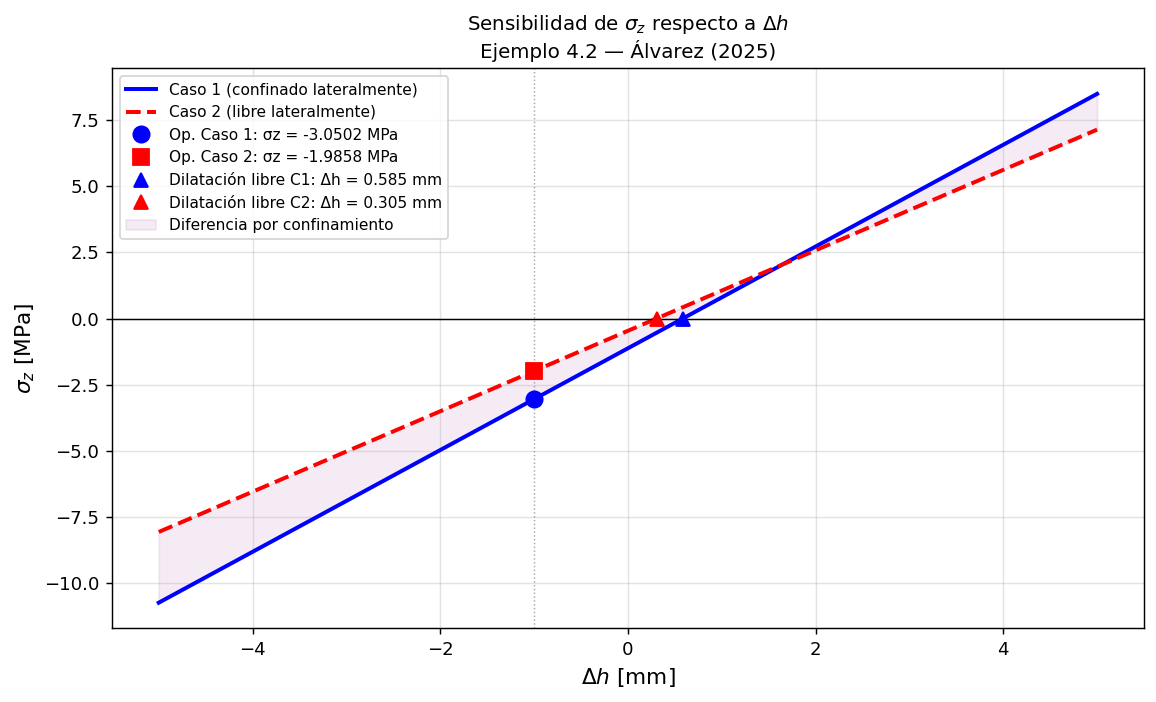

Dilatación libre (σz=0) — Caso 1: Δh = 0.5848 mm
Dilatación libre (σz=0) — Caso 2: Δh = 0.3049 mm
(Con solo el calentamiento, el Caso 1 se dilata menos que el Caso 2,
 porque las paredes generan compresión lateral que retarda la expansión.)


In [22]:
# ─────────────────────────────────────────────────────────────
# FIGURA 4: σz vs Δh  (ambos casos)
# ─────────────────────────────────────────────────────────────
dh_vec = np.linspace(-5e-3, 5e-3, 400)   # −5 mm … +5 mm

sz1_v = (d2*c1_t*h1 + d1*c2_t*h2 + d1*d2*dh_vec) / (d1*h2 + d2*h1)
sz2_v = (E1*E2*(dh_vec - (alpha1*h1 + alpha2*h2)*dT)) / (E1*h2 + E2*h1)

# Punto de deformación libre térmicamente (σz = 0, Δh puro por temperatura)
dh_termico_c1 = -(d2*c1_t*h1 + d1*c2_t*h2) / (d1*d2)
dh_termico_c2 =  (alpha1*h1 + alpha2*h2) * dT

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(dh_vec*1e3, sz1_v/1e6, 'b-',  lw=2.2, label='Caso 1 (confinado lateralmente)')
ax.plot(dh_vec*1e3, sz2_v/1e6, 'r--', lw=2.2, label='Caso 2 (libre lateralmente)')

# Puntos de operación
ax.plot(dh*1e3, sz_c1/1e6, 'bo', ms=9, zorder=5,
        label=f'Op. Caso 1: σz = {sz_c1/1e6:.4f} MPa')
ax.plot(dh*1e3, sz_c2/1e6, 'rs', ms=9, zorder=5,
        label=f'Op. Caso 2: σz = {sz_c2/1e6:.4f} MPa')

# Puntos de dilatación libre (σz = 0)
ax.plot(dh_termico_c1*1e3, 0, 'b^', ms=8, zorder=5,
        label=f'Dilatación libre C1: Δh = {dh_termico_c1*1e3:.3f} mm')
ax.plot(dh_termico_c2*1e3, 0, 'r^', ms=8, zorder=5,
        label=f'Dilatación libre C2: Δh = {dh_termico_c2*1e3:.3f} mm')

ax.axhline(0, color='k', lw=0.8)
ax.axvline(dh*1e3, color='gray', lw=0.8, ls=':', alpha=0.7)
ax.fill_between(dh_vec*1e3, sz1_v/1e6, sz2_v/1e6,
                alpha=0.08, color='purple',
                label='Diferencia por confinamiento')

ax.set_xlabel(r'$\Delta h$ [mm]', fontsize=12)
ax.set_ylabel(r'$\sigma_z$ [MPa]', fontsize=12)
ax.set_title('Sensibilidad de $\\sigma_z$ respecto a $\\Delta h$\n'
             'Ejemplo 4.2 — Álvarez (2025)', fontsize=11)
ax.legend(fontsize=8.5, loc='upper left')
ax.grid(True, alpha=0.35)

plt.tight_layout()
#plt.savefig('fig4_sz_vs_dh.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Dilatación libre (σz=0) — Caso 1: Δh = {dh_termico_c1*1e3:.4f} mm")
print(f"Dilatación libre (σz=0) — Caso 2: Δh = {dh_termico_c2*1e3:.4f} mm")
print("(Con solo el calentamiento, el Caso 1 se dilata menos que el Caso 2,")
print(" porque las paredes generan compresión lateral que retarda la expansión.)")

**Las dos líneas rectas**

Ambos casos son lineales en $\Delta h$, lo cual es consecuencia directa de la ley de Hooke — la relación entre esfuerzo y deformación es siempre proporcional. La línea azul (Caso 1) tiene **mayor pendiente** que la roja (Caso 2), lo que significa que para producir el mismo acortamiento el sistema confinado siempre exige más esfuerzo. Esa diferencia de pendiente es precisamente la diferencia entre el módulo constreñido $M = \lambda + 2G$ y el módulo de Young $E$.

**La zona sombreada**

Es la diferencia de $\sigma_z$ entre ambos casos para cada valor de $\Delta h$. Representa el **sobreesfuerzo que impone el confinamiento lateral**. Nótese que esa diferencia no es constante — se amplifica a medida que $|\Delta h|$ crece, porque las pendientes divergen.

**Los triángulos — dilatación libre térmica**

Son los puntos donde $\sigma_z = 0$, es decir, donde el conjunto se deforma **sin ninguna carga mecánica aplicada**, solo por el calentamiento $\Delta T = 15°C$. 

- Caso 2 (libre): $\Delta h = +0.305$ mm — las pastillas se expanden libremente, cada una según su propio $\alpha$.
- Caso 1 (confinado): $\Delta h = +0.585$ mm — la expansión libre es mayor porque el confinamiento lateral, al impedir la deformación lateral, redirige parte de la expansión térmica hacia la dirección vertical.

Que el Caso 1 tenga mayor dilatación libre que el Caso 2 puede parecer contraintuitivo, pero tiene sentido: las paredes no dejan expandirse lateralmente, así que toda la energía térmica se canaliza en $z$.

**Los puntos de operación (círculo y cuadrado)**

Están en $\Delta h = -1$ mm, que es la condición del ejemplo. Ambos caen en la zona de compresión ($\sigma_z < 0$) y a la izquierda de los triángulos, lo que confirma que para **revertir la dilatación térmica y además lograr un acortamiento adicional** se necesita una compresión sustancial.

**Lectura conjunta**

La gráfica permite responder de un vistazo una pregunta general: *dado cualquier acortamiento o alargamiento deseado bajo este calentamiento, ¿cuánto esfuerzo se necesita en cada caso?* Para valores positivos de $\Delta h$ cercanos a los triángulos, la carga requerida es casi nula — el calentamiento hace casi todo el trabajo. Para valores negativos de $\Delta h$, hay que vencer tanto la expansión térmica como producir la compresión adicional, y el confinamiento encarece ese costo significativamente.

### 8.2 Efecto de la temperatura $\Delta T$ sobre $\sigma_z$

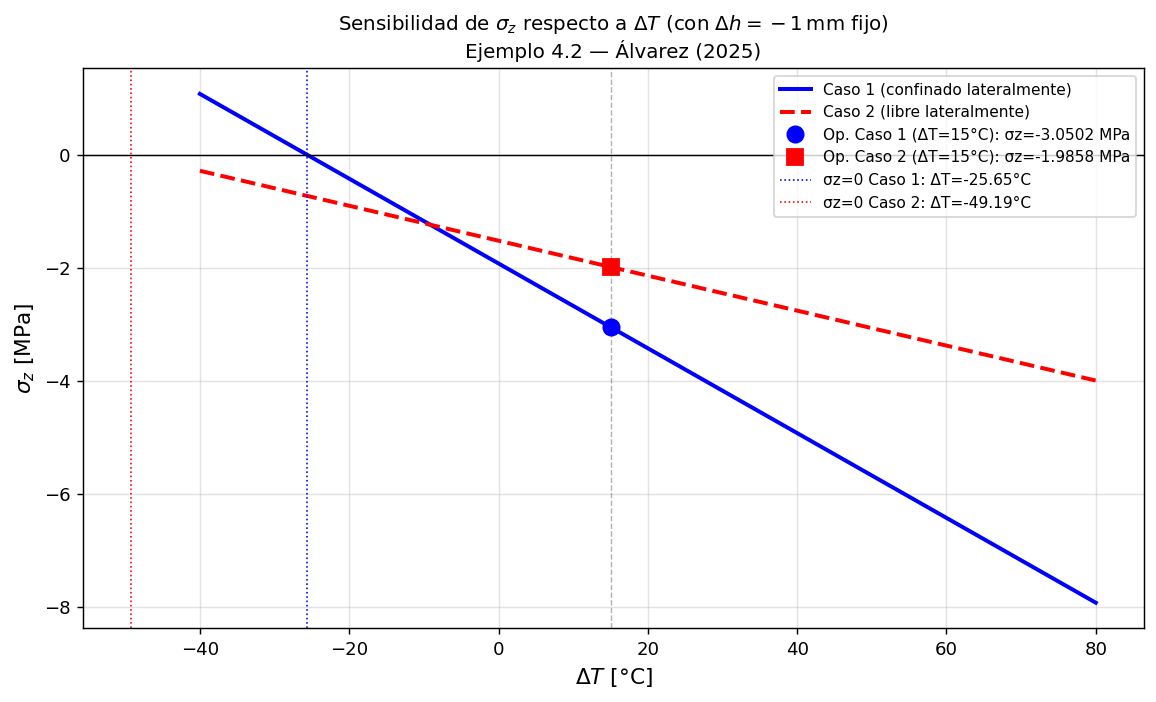

Para ΔT = -25.65°C, el acortamiento Δh=-1mm se logra sin carga externa (Caso 1).
Para ΔT = -49.19°C, el acortamiento Δh=-1mm se logra sin carga externa (Caso 2).


In [23]:
# ─────────────────────────────────────────────────────────────
# FIGURA 5: σz vs ΔT  (manteniendo Δh = −1 mm)
# ─────────────────────────────────────────────────────────────
dT_vec = np.linspace(-40, 80, 400)   # rango de temperatura [°C]

# Recalcular c1, c2 en función de dT_vec
c1_v = E1 * alpha1 * dT_vec / (2*nu1 - 1)
c2_v = E2 * alpha2 * dT_vec / (2*nu2 - 1)

sz1_dT = (d2*c1_v*h1 + d1*c2_v*h2 + d1*d2*dh) / (d1*h2 + d2*h1)
sz2_dT = (E1*E2*(dh - (alpha1*h1 + alpha2*h2)*dT_vec)) / (E1*h2 + E2*h1)

# dT para el cual σz = 0 (no se requiere carga externa)
# Caso 1: d2*c1*h1 + d1*c2*h2 + d1*d2*dh = 0  →  dT tal que (c1,c2 prop. dT)
K_c1 = (d2*E1*alpha1*h1/(2*nu1-1) + d1*E2*alpha2*h2/(2*nu2-1)) / (d1*h2 + d2*h1)
dT_cero_c1 = -d1*d2*dh / ((d2*E1*alpha1*h1/(2*nu1-1) + d1*E2*alpha2*h2/(2*nu2-1)))
dT_cero_c2 = dh / ((alpha1*h1 + alpha2*h2))  # cuando dh = (α1h1+α2h2)ΔT

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(dT_vec, sz1_dT/1e6, 'b-',  lw=2.2, label='Caso 1 (confinado lateralmente)')
ax.plot(dT_vec, sz2_dT/1e6, 'r--', lw=2.2, label='Caso 2 (libre lateralmente)')

# Punto de operación dT = 15 °C
ax.plot(dT, sz_c1/1e6, 'bo', ms=9, zorder=5,
        label=f'Op. Caso 1 (ΔT=15°C): σz={sz_c1/1e6:.4f} MPa')
ax.plot(dT, sz_c2/1e6, 'rs', ms=9, zorder=5,
        label=f'Op. Caso 2 (ΔT=15°C): σz={sz_c2/1e6:.4f} MPa')

# ΔT donde σz = 0
ax.axhline(0, color='k', lw=0.8)
ax.axvline(dT_cero_c1, color='b', lw=0.9, ls=':',
           label=f'σz=0 Caso 1: ΔT={dT_cero_c1:.2f}°C')
ax.axvline(dT_cero_c2, color='r', lw=0.9, ls=':',
           label=f'σz=0 Caso 2: ΔT={dT_cero_c2:.2f}°C')
ax.axvline(dT, color='gray', lw=0.8, ls='--', alpha=0.6)

ax.set_xlabel(r'$\Delta T$ [°C]', fontsize=12)
ax.set_ylabel(r'$\sigma_z$ [MPa]', fontsize=12)
ax.set_title('Sensibilidad de $\\sigma_z$ respecto a $\\Delta T$ '
             '(con $\\Delta h = -1\\,\\text{mm}$ fijo)\n'
             'Ejemplo 4.2 — Álvarez (2025)', fontsize=11)
ax.legend(fontsize=8.5, loc='upper right')
ax.grid(True, alpha=0.35)

plt.tight_layout()
#plt.savefig('fig5_sz_vs_dT.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Para ΔT = {dT_cero_c1:.2f}°C, el acortamiento Δh=-1mm se logra sin carga externa (Caso 1).")
print(f"Para ΔT = {dT_cero_c2:.2f}°C, el acortamiento Δh=-1mm se logra sin carga externa (Caso 2).")

**Las dos líneas rectas**

Nuevamente ambos casos son lineales, ahora en $\Delta T$. Las pendientes son **negativas**: a mayor calentamiento, se necesita mayor compresión para lograr el mismo acortamiento $\Delta h = -1$ mm. Esto es intuitivo — cuanto más se calienta el sistema, más quiere expandirse, y mayor esfuerzo de compresión se necesita para frenarlo y además acortarlo 1 mm.

La línea azul (Caso 1) tiene **pendiente más negativa** que la roja (Caso 2), lo que significa que el sistema confinado es más sensible a la temperatura. Eso se explica porque en el Caso 1 el término térmico actúa a través del módulo constreñido $M$, que es mayor que $E$.


**Las líneas punteadas verticales — donde $\sigma_z = 0$**

Son las temperaturas a las cuales $\Delta h = -1$ mm se logra **sin ninguna carga mecánica**. Solo el enfriamiento del sistema produce el acortamiento deseado.

- Caso 1: $\Delta T = -25.65°C$ — se necesita menos enfriamiento porque el confinamiento amplifica el efecto térmico en dirección $z$.
- Caso 2: $\Delta T = -49.19°C$ — se necesita más enfriamiento porque sin confinamiento la contracción térmica vertical es menor.

A la izquierda de cada línea punteada, $\sigma_z > 0$: el enfriamiento es tan intenso que el sistema querría acortarse más de 1 mm, y hay que **traccionarlo** para limitarlo exactamente a ese valor.

**Los puntos de operación**

Están en $\Delta T = 15\,^\circ$C, que es la condición del ejemplo. Ambos caen bien dentro de la zona de compresión, a la derecha de sus respectivas líneas punteadas — coherente con que el calentamiento se opone al acortamiento requerido.


**Lectura conjunta**

La gráfica responde a una pregunta práctica: *si el ambiente cambia de temperatura, ¿cómo varía la carga que debo aplicar para mantener el mismo desplazamiento?* La respuesta es lineal pero con sensibilidades muy distintas según si el sistema está confinado o no. Para variaciones grandes de temperatura — por ejemplo en estructuras expuestas a ciclos térmicos amplios — ignorar este efecto puede llevar a subestimar significativamente la carga requerida, especialmente en el Caso 1.

### 8.3 Mapa de contorno: $\sigma_z$ en función de $\Delta h$ y $\Delta T$ simultáneamente

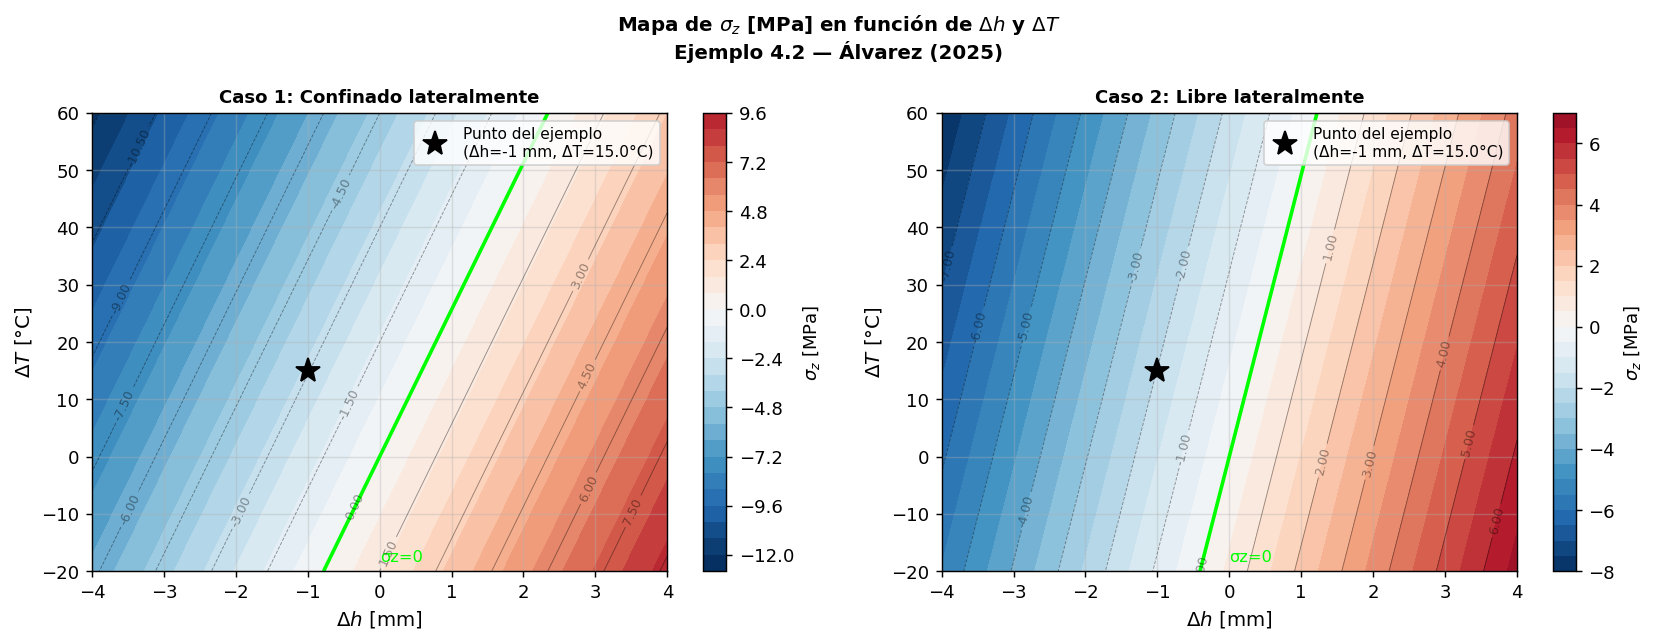

In [24]:
# ─────────────────────────────────────────────────────────────
# FIGURA 6: Mapa de contorno σz(Δh, ΔT)
# ─────────────────────────────────────────────────────────────
dh_g = np.linspace(-4e-3, 4e-3, 200)   # [m]
dT_g = np.linspace(-20,   60,   200)   # [°C]
DH, DT_ = np.meshgrid(dh_g, dT_g)

C1_g = E1 * alpha1 * DT_ / (2*nu1 - 1)
C2_g = E2 * alpha2 * DT_ / (2*nu2 - 1)

SZ_c1 = (d2*C1_g*h1 + d1*C2_g*h2 + d1*d2*DH) / (d1*h2 + d2*h1)
SZ_c2 = (E1*E2*(DH - (alpha1*h1 + alpha2*h2)*DT_)) / (E1*h2 + E2*h1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, SZ, titulo, caso in zip(
        axes,
        [SZ_c1, SZ_c2],
        ['Caso 1: Confinado lateralmente', 'Caso 2: Libre lateralmente'],
        [1, 2]):

    vmax = max(abs(SZ.min()), abs(SZ.max())) / 1e6
    cf = ax.contourf(DH*1e3, DT_, SZ/1e6, levels=30,
                     cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    cs = ax.contour(DH*1e3, DT_, SZ/1e6, levels=15,
                    colors='k', linewidths=0.5, alpha=0.4)
    ax.clabel(cs, fontsize=7, fmt='%.2f')

    # σz = 0 (línea de carga cero)
    ax.contour(DH*1e3, DT_, SZ/1e6, levels=[0],
               colors='lime', linewidths=2)
    ax.text(0.5, 0.02, 'σz=0', transform=ax.transAxes,
            color='lime', fontsize=9)

    # Punto de operación del ejemplo
    ax.plot(dh*1e3, dT, 'k*', ms=14, zorder=5,
            label=f'Punto del ejemplo\n(Δh={dh*1e3:.0f} mm, ΔT={dT}°C)')

    plt.colorbar(cf, ax=ax, label=r'$\sigma_z$ [MPa]')
    ax.set_xlabel(r'$\Delta h$ [mm]', fontsize=11)
    ax.set_ylabel(r'$\Delta T$ [°C]', fontsize=11)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8.5, loc='upper right')

fig.suptitle('Mapa de $\\sigma_z$ [MPa] en función de $\\Delta h$ y $\\Delta T$\n'
             'Ejemplo 4.2 — Álvarez (2025)', fontsize=11, fontweight='bold')
plt.tight_layout()
#plt.savefig('fig6_mapa_contorno.png', dpi=150, bbox_inches='tight')
plt.show()

Este gráfico unifica los dos análisis de sensibilidad anteriores en uno solo. En lugar de variar $\Delta h$ o $\Delta T$ por separado, aquí ambos varían **simultáneamente**, y el color indica el valor de $\sigma_z$ resultante.

**Cómo leerlo**

Cada punto del mapa es una combinación $(\Delta h,\, \Delta T)$. El color dice qué esfuerzo $\sigma_z$ se necesita para esa combinación:

- **Azul** → compresión ($\sigma_z < 0$): hay que empujar las pastillas
- **Rojo** → tracción ($\sigma_z > 0$): hay que jalarlas
- **Blanco** → $\sigma_z \approx 0$: los efectos térmico y mecánico se equilibran solos

**La línea verde — $\sigma_z = 0$**

Es la frontera más importante del gráfico. Separa el régimen de compresión del de tracción. Todo punto a la **izquierda y arriba** de esa línea requiere compresión; todo punto a la **derecha y abajo** requiere tracción.

Su inclinación tiene un significado físico directo: muestra cómo se intercambian $\Delta h$ y $\Delta T$ para mantener $\sigma_z = 0$. Si el sistema se calienta más, necesita acortarse más para que no se requiera carga externa, y viceversa.

**Las curvas de contorno (líneas diagonales punteadas)**

Cada curva une todos los pares $(\Delta h, \Delta T)$ que producen el mismo $\sigma_z$. Son rectas paralelas porque la relación es lineal en ambas variables — confirma que la ley de Hooke con temperatura es una función bilineal de $(\Delta h, \Delta T)$.

**La estrella — punto del ejemplo**

Está en $(\Delta h = -1\,\text{mm},\, \Delta T = 15°\text{C})$. En ambos casos cae en la zona azul, bien a la izquierda de la línea verde, lo que confirma que se necesita compresión. En el Caso 1 la estrella está más adentro en la zona azul que en el Caso 2, coherente con que requiere mayor esfuerzo.

**Diferencia entre los dos mapas**

Las curvas de contorno del Caso 1 están más juntas que las del Caso 2 para el mismo rango de colores. Eso significa que en el Caso 1 **pequeños cambios de $\Delta h$ o $\Delta T$ producen cambios mayores de $\sigma_z$** — el sistema confinado es más sensible a ambas variables simultáneamente.

**Lectura práctica**

El mapa responde de un vistazo a preguntas del tipo: *si la temperatura sube 10 °C más de lo previsto, ¿cuánto debo cambiar el desplazamiento impuesto para no sobrecargar el sistema?* La respuesta es moverse a lo largo de una curva de contorno, desplazándose hacia la derecha en $\Delta h$ para compensar el aumento de $\Delta T$.

## 9. Interpretación física

### 9.1 Efecto del confinamiento lateral

En el **Caso 1**, las paredes de la caja impiden toda deformación lateral
($\varepsilon_x = \varepsilon_y = 0$). Esto genera esfuerzos laterales de
confinamiento $\sigma_x = \sigma_y = \lambda\,\varepsilon_z + c$, que son de
**tracción** en ambas pastillas (las paredes jalan las pastillas cuando estas
intentan comprimirse lateralmente bajo la carga $\sigma_z$).

Como consecuencia, la rigidez vertical aparente queda gobernada por el
**módulo constreñido**:

$$
M = \lambda + 2G = \frac{E(1-\nu)}{(1+\nu)(1-2\nu)} > E
$$

Por ello, el Caso 1 requiere **más esfuerzo** que el Caso 2 para producir el
mismo acortamiento $\Delta h$.

### 9.2 Efecto térmico

El calentamiento $\Delta T = 15°\text{C}$ tiende a **dilatar** ambas
pastillas. En ausencia de carga mecánica ($\sigma_z = 0$), el conjunto se
expande libremente. Para lograr un **acortamiento** de 1 mm a pesar del
calentamiento, se necesita aplicar una compresión $\sigma_z < 0$ mayor que la
que sería necesaria en condiciones isotérmicas.

La tabla siguiente muestra la comparación con el caso isotérmico ($\Delta T = 0$):

In [25]:
# ─────────────────────────────────────────────────────────────
# COMPARACIÓN ISOTÉRMICO vs. TÉRMICA
# ─────────────────────────────────────────────────────────────
# Caso isotérmico (ΔT = 0)
c1_iso = c_thermal(E1, alpha1, 0.0, nu1)
c2_iso = c_thermal(E2, alpha2, 0.0, nu2)
sz_c1_iso = (d2*c1_iso*h1 + d1*c2_iso*h2 + d1*d2*dh) / (d1*h2 + d2*h1)
sz_c2_iso = (E1*E2*(dh - 0)) / (E1*h2 + E2*h1)

print("Comparación ΔT = 0 vs ΔT = 15°C (para Δh = −1 mm)")
print("─" * 58)
print(f"{'':30} {'ΔT=0':>12} {'ΔT=15°C':>12}")
print("─" * 58)
print(f"{'σz Caso 1 [MPa]':30} {sz_c1_iso/1e6:>12.5f} {sz_c1/1e6:>12.6f}")
print(f"{'σz Caso 2 [MPa]':30} {sz_c2_iso/1e6:>12.5f} {sz_c2/1e6:>12.6f}")
print(f"{'ΔσzC1 por temperatura [MPa]':30} {'—':>12} {(sz_c1-sz_c1_iso)/1e6:>12.6f}")
print(f"{'ΔσzC2 por temperatura [MPa]':30} {'—':>12} {(sz_c2-sz_c2_iso)/1e6:>12.6f}")
print("─" * 58)
print("\nEl calentamiento exige mayor compresión para lograr el mismo Δh.")

Comparación ΔT = 0 vs ΔT = 15°C (para Δh = −1 mm)
──────────────────────────────────────────────────────────
                                       ΔT=0      ΔT=15°C
──────────────────────────────────────────────────────────
σz Caso 1 [MPa]                    -1.92463    -3.050185
σz Caso 2 [MPa]                    -1.52174    -1.985793
ΔσzC1 por temperatura [MPa]               —    -1.125553
ΔσzC2 por temperatura [MPa]               —    -0.464054
──────────────────────────────────────────────────────────

El calentamiento exige mayor compresión para lograr el mismo Δh.


### 9.3 Cuantificación del efecto térmico sobre $\sigma_z$

Una pregunta natural es: ¿qué tanto aporta el calentamiento $\Delta T$ al esfuerzo
requerido? Para responderla, se compara la solución del ejemplo ($\Delta T = 15°C$)
contra el caso isotérmico ($\Delta T = 0$), manteniendo fijo $\Delta h = -1\,\text{mm}$.

La diferencia no es un efecto de segundo orden: el término térmico modifica
sustancialmente la magnitud de $\sigma_z$, porque las pastillas, especialmente la
pastilla 1, con $\alpha_1 = 77x10^{-6}°C$, tienden a **dilatarse** bajo el
calentamiento, oponiéndose al acortamiento deseado. Para vencer esa expansión térmica
además de lograr el acortamiento mecánico, se requiere una compresión notablemente mayor.

En el Caso 1 (confinado), el efecto es aún más pronunciado porque el confinamiento
lateral amplifica la participación del término $c_i = E_i\alpha_i\Delta T/(2\nu_i - 1)$
en la expresión de $\sigma_z$.

In [26]:
# ─────────────────────────────────────────────────────────────
# EFECTO TÉRMICO: ΔT = 0  vs.  ΔT = 15 °C  (Δh = −1 mm fijo)
# ─────────────────────────────────────────────────────────────

# Caso isotérmico (ΔT = 0)
c1_iso = c_thermal(E1, alpha1, 0.0, nu1)   # = 0
c2_iso = c_thermal(E2, alpha2, 0.0, nu2)   # = 0

sz_c1_iso = (d2*c1_iso*h1 + d1*c2_iso*h2 + d1*d2*dh) / (d1*h2 + d2*h1)
sz_c2_iso = (E1*E2*(dh - 0.0)) / (E1*h2 + E2*h1)

# Diferencias absolutas y porcentuales
dsz_c1     = sz_c1     - sz_c1_iso           # aporte de ΔT al esfuerzo (Caso 1)
dsz_c2     = sz_c2     - sz_c2_iso           # aporte de ΔT al esfuerzo (Caso 2)
pct_c1     = abs(dsz_c1 / sz_c1_iso) * 100
pct_c2     = abs(dsz_c2 / sz_c2_iso) * 100

# ── Tabla formateada ─────────────────────────────────────────
sep  = "═" * 68
sep2 = "─" * 68
fmt  = "{:<28} {:>10} {:>10} {:>10} {:>8}"

print(sep)
print(f"{'EFECTO DEL CALENTAMIENTO ΔT = 15 °C  (Δh = −1 mm fijo)':^68}")
print(sep)
print(fmt.format("Magnitud", "ΔT = 0", "ΔT = 15°C", "Diferencia", "  %"))
print(sep2)
print(fmt.format(
    "σz  Caso 1  [MPa]",
    f"{sz_c1_iso/1e6:.5f}",
    f"{sz_c1/1e6:.5f}",
    f"{dsz_c1/1e6:.5f}",
    f"{pct_c1:.1f}%"))
print(fmt.format(
    "F   Caso 1  [kN]",
    f"{sz_c1_iso*A/1e3:.4f}",
    f"{sz_c1*A/1e3:.4f}",
    f"{dsz_c1*A/1e3:.4f}",
    f"{pct_c1:.1f}%"))
print(sep2)
print(fmt.format(
    "σz  Caso 2  [MPa]",
    f"{sz_c2_iso/1e6:.5f}",
    f"{sz_c2/1e6:.5f}",
    f"{dsz_c2/1e6:.5f}",
    f"{pct_c2:.1f}%"))
print(fmt.format(
    "F   Caso 2  [kN]",
    f"{sz_c2_iso*A/1e3:.4f}",
    f"{sz_c2*A/1e3:.4f}",
    f"{dsz_c2*A/1e3:.4f}",
    f"{pct_c2:.1f}%"))
print(sep)

════════════════════════════════════════════════════════════════════
       EFECTO DEL CALENTAMIENTO ΔT = 15 °C  (Δh = −1 mm fijo)       
════════════════════════════════════════════════════════════════════
Magnitud                         ΔT = 0  ΔT = 15°C Diferencia        %
────────────────────────────────────────────────────────────────────
σz  Caso 1  [MPa]              -1.92463   -3.05019   -1.12555    58.5%
F   Caso 1  [kN]               -19.2463   -30.5019   -11.2555    58.5%
────────────────────────────────────────────────────────────────────
σz  Caso 2  [MPa]              -1.52174   -1.98579   -0.46405    30.5%
F   Caso 2  [kN]               -15.2174   -19.8579    -4.6405    30.5%
════════════════════════════════════════════════════════════════════


El calentamiento ΔT = 15 °C incrementa el esfuerzo requerido
en un 58.5% en el Caso 1 y un 30.5% en el Caso 2.

El mayor efecto relativo en el Caso 1 se debe al confinamiento
lateral: al impedirse la expansión térmica en x e y, toda la
dilatación debe ser contrarrestada en dirección z, actuando
sobre el módulo constreñido M = λ+2G > E.

## Conclusiones

Del análisis completo del Ejemplo 4.2 se pueden extraer cuatro conclusiones sobre los esfuerzos causados por temperatura:

**1. La temperatura genera esfuerzos incluso sin carga mecánica aplicada**

En el Caso 1, con $\sigma_z = 0$, el calentamiento produce esfuerzos laterales de confinamiento $\sigma_x = \sigma_y \neq 0$ en ambas pastillas. Esto significa que una estructura confinada que experimenta un cambio de temperatura está sometida a un estado de esfuerzos no trivial aunque nadie la esté cargando externamente. Este efecto es completamente invisible para la ley de Hooke clásica.

**2. El efecto térmico no es despreciable cuantitativamente**

El calentamiento de solo $\Delta T = 15°$ C incrementó el esfuerzo requerido en un 58.5% para el Caso 1 y un 30.5% para el Caso 2. En diseño estructural, ignorar este aporte equivale a subestimar la carga real en más de la mitad en sistemas confinados. No es un efecto de segundo orden.

**3. El confinamiento amplifica el efecto térmico**

La sensibilidad a la temperatura es significativamente mayor en el sistema confinado porque la expansión lateral queda impedida y toda la dilatación térmica se canaliza en la dirección de carga. Esto se refleja en que el término térmico actúa sobre el módulo constreñido $M = \lambda + 2G$, que es mayor que $E$. A mayor temperatura, mayor es la diferencia entre los dos casos — el confinamiento y la temperatura se potencian mutuamente.


**4. Existe una temperatura crítica que elimina la necesidad de carga externa**

Para cada condición de desplazamiento impuesto existe un $\Delta T$ específico con el cual $\sigma_z = 0$. Esto tiene una implicación práctica importante: en ciertos rangos de temperatura, la estructura se deforma hasta el valor deseado por sí sola, sin intervención mecánica. Por encima de ese umbral, la carga debe invertirse de compresión a tracción. Dimensionar sin considerar este punto de cruce puede llevar a un error cualitativo, no solo cuantitativo.


**Síntesis**

Los esfuerzos térmicos no son un refinamiento opcional del análisis, son una componente estructural del estado de esfuerzos que modifica tanto la magnitud como el signo de los esfuerzos requeridos, y cuya importancia relativa crece precisamente en las condiciones más restrictivas, que son las más comunes en ingeniería: sistemas confinados bajo cargas combinadas.